# Adaptive Noise Gate
An adaptive noise gate where the thresholds track recent frame energies, allowing the system to adjust dynamically to changing noise environments.

## Creating a test signal

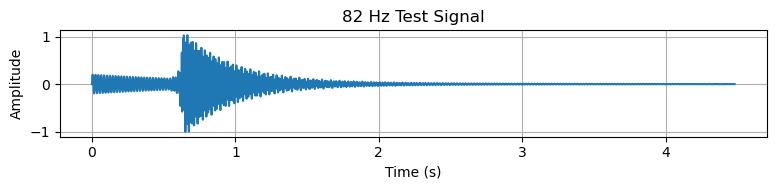

In [6]:
import numpy as np
from utils import (create_guitar_signal,  
                   create_sinewave, 
                   plot_gate_debug,
                   plot_signal,
                   load_floats_csv)
frame_len = 1024
freq = 82
fs = 8000
N1, N2 = 30,  5
hum_freq, hum_amp = 50, 0.2

s1, _ = create_guitar_signal(fs, freq, N1*frame_len, amplitude=1, decay_rate=3.0)
s2, _ = create_guitar_signal(fs, freq, N2*frame_len, amplitude=1, decay_rate=45.0)
s3, _ = create_sinewave(fs, hum_freq, (N1 + N2)*frame_len, hum_amp,1)

s2_rev = s2[::-1]
signal = np.concatenate([s2_rev, s1]) + s3
time = np.arange(len(signal)) / fs

plot_signal(signal=signal, time=time, title=f"{freq} Hz Test Signal", figsize=(8, 2))

## Adaptive Noise Gate
An adaptive noise gate that processes audio one frame at a time while maintaining a rolling history of the last 20 frames below the threshold. The noise floor is estimated from this history, and the open/close thresholds drift with recent frame energies, allowing the gate to adapt dynamically to varying background noise levels and environments.

In [7]:
import numpy as np
from collections import deque
CLOSED, OPEN = 0,1 

class FrameState:
    def __init__(self,
                 Nbuf=20,
                 floor_pct=10,
                 delta_on=9.0,
                 delta_off=4.0,
                 hang_frames=8,
                 include_open=True):
        self.Nbuf = Nbuf
        self.floor_pct = floor_pct
        self.delta_on = delta_on
        self.delta_off = delta_off
        self.hang_frames = hang_frames
        self.include_open = include_open
        self.buf = deque(maxlen=Nbuf)
        self.gate = CLOSED
        self.hang = 0
        self.init = False

def adaptive_noise_gate_step(frame, st: FrameState):
    energy = np.sum(frame**2)
    EPS = 1e-20
    E_db = 10.0 * np.log10(energy if energy > EPS else EPS)

    # --- bootstrap (first frame) ---
    if not st.init:
        st.buf.clear(); st.buf.append(E_db)
        F_raw = np.percentile(np.array(st.buf), st.floor_pct)
        st.F_prev = F_raw                  # seed stored floor
        F = st.F_prev
        Ton, Toff = F + st.delta_on, F + st.delta_off
        st.gate = CLOSED
        st.hang = 0
        st.init = True
        return E_db, F, Ton, Toff, st.gate

    # --- buffer update (learn while closed; open only if include_open) ---
    if (st.gate == CLOSED) or st.include_open:
        st.buf.append(E_db)

    # --- raw percentile floor from buffer ---
    F_raw = np.percentile(np.array(st.buf), st.floor_pct)

    # --- leaky-learn while open (tiny, and only from not-too-hot frames) ---
    # uses previous thresholds (Ton_prev) for the cap comparison
    if not hasattr(st, "F_prev"):
        st.F_prev = F_raw
    Ton_prev = st.F_prev + st.delta_on

    alpha = 0.02   # leak factor
    cap   = 6.0    # don't learn frames hotter than (Ton_prev - cap)

    if st.gate == OPEN and E_db <= (Ton_prev - cap):
        st.F_prev = (1.0 - alpha) * st.F_prev + alpha * E_db
    else:
        # normal update: when closed, follow F_raw; when open and too hot, hold
        if st.gate == CLOSED:
            st.F_prev = F_raw

    F = st.F_prev
    Ton, Toff = F + st.delta_on, F + st.delta_off

    # --- gate with hangover ---
    if st.gate == CLOSED:
        if E_db >= Ton:
            st.gate = OPEN
            st.hang = st.hang_frames
    else:
        if (E_db <= Toff) and (st.hang == 0):
            st.gate = CLOSED
        else:
            st.hang = max(st.hang - 1, 0)

    return E_db, F, Ton, Toff, st.gate

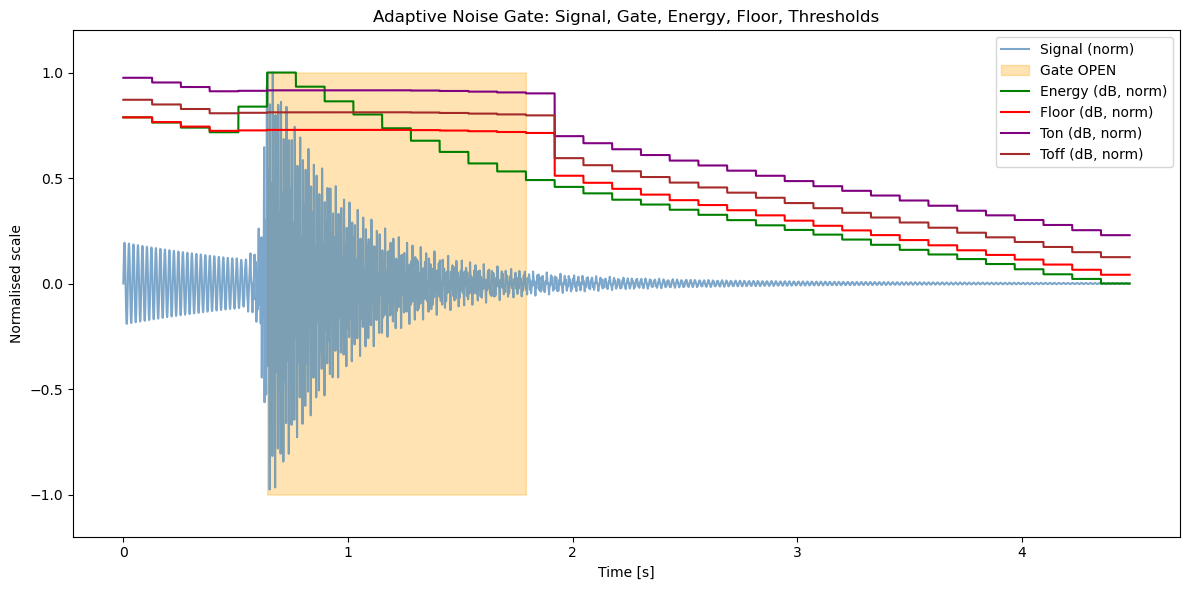

In [8]:
def run_adaptive_gate(signal, frame_len, fs, state_cls=FrameState):

    n_frames = len(signal) // frame_len
    signal = signal[: n_frames * frame_len]
    time = np.arange(len(signal)) / fs

    Ton_list, Toff_list, E_db_list, F_list, gate_list = [], [], [], [], []
    state = state_cls()

    for i in range(n_frames):
        frame = signal[i*frame_len : (i+1)*frame_len]
        E_db, F, Ton, Toff, gate = adaptive_noise_gate_step(frame, state)

        Ton_list.append(np.full(frame_len, Ton))
        Toff_list.append(np.full(frame_len, Toff))
        E_db_list.append(np.full(frame_len, E_db))
        F_list.append(np.full(frame_len, F))
        gate_list.append(np.full(frame_len, gate))

    Ton_arr  = np.concatenate(Ton_list)
    Toff_arr = np.concatenate(Toff_list)
    E_db_arr = np.concatenate(E_db_list)
    F_arr    = np.concatenate(F_list)
    gate_arr = np.concatenate(gate_list)

    return time, signal, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr


t, x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr = \
    run_adaptive_gate(signal, frame_len=1024, fs=8000.0)

plot_gate_debug(time, signal, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr)

## Real Piezo Signal

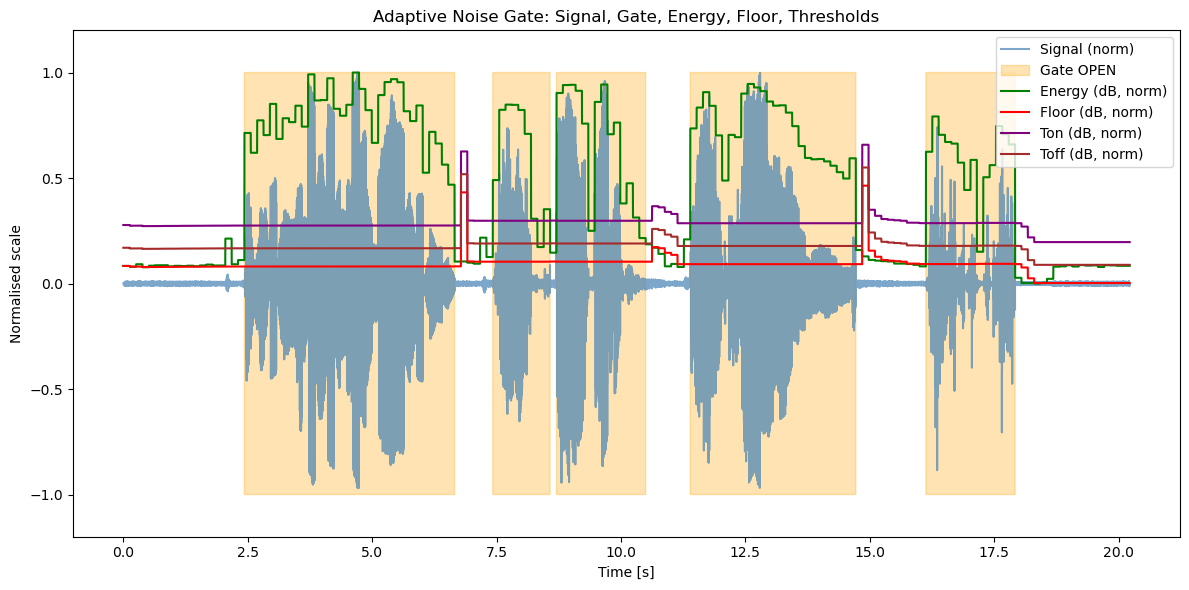

In [9]:
signal_E2 = load_floats_csv("data/E2_signal.csv")
signal_A2 = load_floats_csv("data/A2_signal.csv")
signal_B3 = load_floats_csv("data/B3_signal.csv")
signal_floor = load_floats_csv("data/noise_floor.csv")
signal_bumps = load_floats_csv("data/bumps_signal.csv")

signal = np.concatenate([signal_floor, 
                         signal_B3, 
                         signal_A2, 
                         signal_E2, 
                         signal_bumps, 
                         signal_floor])


t, x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr = \
    run_adaptive_gate(signal, frame_len=1024, fs=8000.0)

plot_gate_debug(t,x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr)



## Adaptive noise floor test
By introducing a slowly varying noise floor, we can observe how the adaptive gate adjusts its thresholds in real time. The gate follows the drifting floor while still opening cleanly for true note onsets.


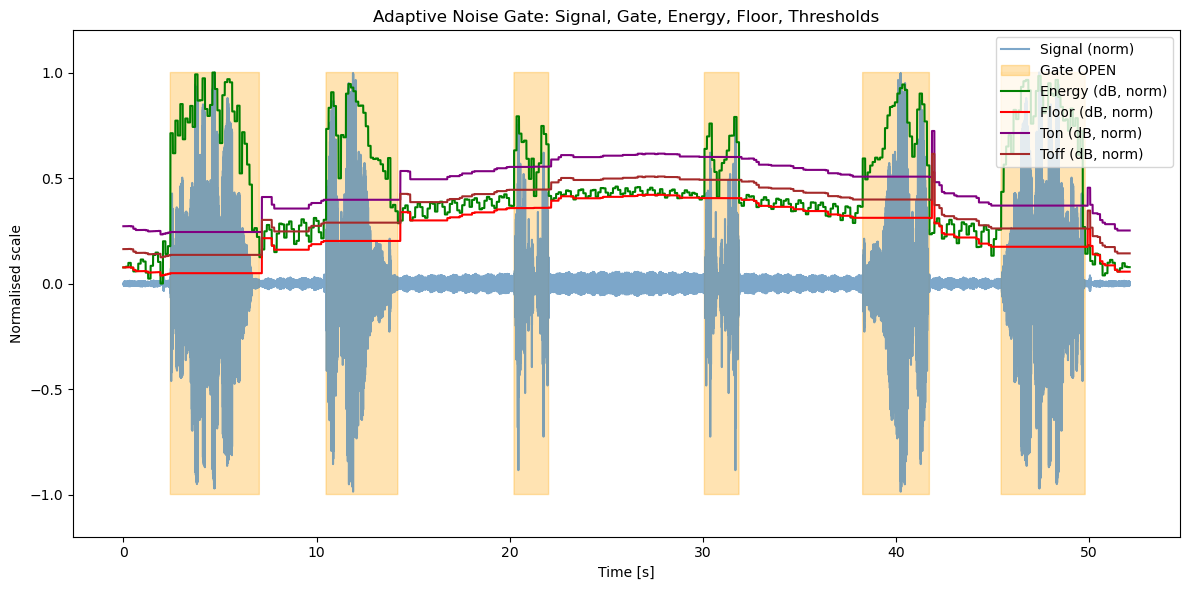

In [10]:

signal = np.concatenate([signal_floor, 
                         signal_B3, 
                         signal_floor, 
                         signal_floor,
                         signal_E2, 
                         signal_floor, 
                         signal_floor,
                         signal_floor,
                         signal_bumps,
                         signal_floor,
                         signal_floor])


hum, _ = create_sinewave(fs, 50, len(signal), 1.0, 0)
ramp = np.linspace(0, 0.05, len(signal))
hum = hum * ramp
signal = signal + hum
signal = np.concatenate([signal, signal[::-1]])
t, x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr = \
    run_adaptive_gate(signal, frame_len=1024, fs=8000.0)

plot_gate_debug(t,x, E_db_arr, F_arr, Ton_arr, Toff_arr, gate_arr)